In [26]:
import sys
sys.path.extend(['/home/mawa/PycharmProjects/polarspike'])
from IPython.display import display, HTML
from polarspike import Overview, recording_overview, spiketrain_plots, colour_template, quality_tests
import polars as pl
from bokeh.io import output_notebook
from bokeh.plotting import show
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

output_notebook()
# If you want interactive plots:
%matplotlib widget

Loading BokehJS ...

In [27]:
def generate_chirp_data(start_freq, end_freq, duration, refresh_rate, max_power=4095):
    """
    Translates the C++ freq_chirp_template logic into Python.
    Returns time, brightness values, and instantaneous frequency arrays.
    """
    # 1. Setup constants (matching C++ logic)
    num_cycles = int(duration * refresh_rate)

    # Calculate beta (growth rate)
    # C++: log(end / start) / duration
    beta = np.log(end_freq / start_freq) / duration

    # 2. Generate Time Array
    # C++: i / refresh_rate
    t = np.linspace(0, duration, num_cycles, endpoint=False)

    # 3. Calculate Exponential Term for all t
    # C++: exp_bt = exp(beta * t)
    exp_bt = np.exp(beta * t)

    # 4. Calculate Frequency at time t
    # C++: freq = start_freq * exp_bt
    freqs = start_freq * exp_bt

    # 5. Calculate Correct Instantaneous Phase
    # C++: phase = 2 * PI * (start / beta) * (exp_bt - 1)
    phase = 2 * np.pi * (start_freq / beta) * (exp_bt - 1)

    # 6. Calculate Sine Value
    # C++: value = sin(phase)
    raw_sine = np.sin(phase)

    # 7. Scale to LED Brightness (0 to max_power)
    # C++: (value + 1.0f) * max_power / 2.0f
    chirp_signal = (raw_sine + 1.0) * max_power / 2.0
    chirp_signal = chirp_signal.astype(int)

    return t, chirp_signal, freqs


# --- Configuration (Matching your snippets) ---
start_freq = 1  # Hz
end_freq = 30  # Hz
duration = 30  # Seconds
refresh_rate = 300  # Hz

# --- Generate Data ---
time, chirp_real, freq_actual = generate_chirp_data(
    start_freq, end_freq, duration, refresh_rate
)

# --- Output Formatting (Matching your second snippet) ---
# Your snippet padded the data into a larger array.
# Replicating that structure here:

total_length_sec = 35
total_samples = int(total_length_sec * refresh_rate) - 1  # Based on your snippet length

# Create the full container arrays filled with zeros
chirp_complete = np.zeros(total_samples)
c_freqs = np.zeros(total_samples)
full_time_axis = np.arange(0, total_length_sec - 1 / refresh_rate, 1 / refresh_rate)

# Define offset (Your snippet used 3 seconds padding: 300 * 3)
offset = 300 * 3
end_idx = offset + len(chirp_real)

# Insert the generated chirp into the complete arrays
# Ensure we don't overflow if the calculated lengths differ slightly due to rounding
limit = min(len(chirp_complete), end_idx)
insert_len = limit - offset

if insert_len > 0:
    chirp_complete[offset:limit] = chirp_real[:insert_len]
    c_freqs[offset:limit] = freq_actual[:insert_len]


In [28]:
# def plot_raster_with_mean_chirp(
#     spikes,
#     full_time_axis,
#     pwm_trace,
#     cell_thresholds,
#     single_cells,
#     t_start=0,
#     t_end=33,
#     bin_size=0.05
# ):

#     # =================================================
#     # TIME COLUMN
#     # =================================================
#     time_col = (
#         "times_relative"
#         if "times_relative" in spikes.columns
#         else "times"
#     )

#     df = spikes[
#         (spikes[time_col] >= t_start) &
#         (spikes[time_col] <= t_end)
#     ].copy()

#     # =================================================
#     # PSTH
#     # =================================================
#     bins = np.arange(t_start, t_end + bin_size, bin_size)
#     bin_centers = (bins[:-1] + bins[1:]) / 2

#     counts_hist, _ = np.histogram(df[time_col], bins=bins)
#     n_cells = df["cell_index"].nunique()
#     psth = counts_hist / (bin_size * n_cells)

#     # =================================================
#     # CELL ORDERING (BY FIRING RATE)
#     # =================================================
#     present_cells = set(df["cell_index"].unique())

#     duration = t_end - t_start

#     spike_counts = df.groupby("cell_index").size()
#     firing_rate = spike_counts / duration

#     firing_rate = firing_rate.reindex(present_cells, fill_value=0)

#     sorted_cells = firing_rate.sort_values(ascending=True).index.values

#     cell_to_y = {
#         cell: len(sorted_cells) - 1 - i
#         for i, cell in enumerate(sorted_cells)
#     }

#     # =================================================
#     # FIGURE
#     # =================================================
#     fig = plt.figure(figsize=(14, 10))
#     gs = fig.add_gridspec(5, 1, height_ratios=[1, 1, 3, 1, 1], hspace=0.05)

#     ax_freq = fig.add_subplot(gs[0])
#     ax_psth = fig.add_subplot(gs[1], sharex=ax_freq)
#     ax_raster = fig.add_subplot(gs[2], sharex=ax_freq)
#     ax_s1 = fig.add_subplot(gs[3], sharex=ax_freq)
#     ax_s2 = fig.add_subplot(gs[4], sharex=ax_freq)

#     # =================================================
#     # BACKGROUND
#     # =================================================
#     for ax in [ax_freq, ax_psth, ax_raster, ax_s1, ax_s2]:
#         ax.set_facecolor("#e6e6e6")

#     # =================================================
#     # PWM TRACE (TOP)
#     # =================================================
#     mask = (full_time_axis >= t_start) & (full_time_axis <= t_end)

#     ax_freq.plot(
#         full_time_axis[mask],
#         pwm_trace[mask],
#         color="darkgreen",
#         linewidth=1.0
#     )

#     ax_freq.set_ylabel("Chirp\n intensity", fontsize = 13)
#     ax_freq.set_ylim(0, np.max(pwm_trace))
#     ax_freq.set_yticks([0, np.max(pwm_trace)])
#     ax_freq.set_yticklabels([0, 1])
#     ax_freq.tick_params(axis="x", bottom=True, labelbottom=False)

#     # =================================================
#     # PSTH
#     # =================================================
#     ax_psth.plot(bin_centers, psth, color="black", linewidth=1.5)
#     ax_psth.set_ylabel("Firing rate\n(spikes/s/cell)", fontsize = 13)
#     ax_psth.set_xlim(t_start, t_end)
#     ax_psth.tick_params(axis="x", bottom=False, labelbottom=False)

#     # =================================================
#     # POPULATION RASTER
#     # =================================================
#     for _, row in df.iterrows():
#         cell = row["cell_index"]

#         if cell not in cell_to_y:
#             continue

#         y = cell_to_y[cell]

#         ax_raster.vlines(
#             row[time_col],
#             y - 0.4,
#             y + 0.4,
#             color="black",
#             linewidth=0.5
#         )

#     ax_raster.set_ylabel("Cell", fontsize=13)
#     ax_raster.set_xlim(t_start, t_end)
#     ax_raster.set_ylim(-0.5, len(sorted_cells) - 0.5)
#     ax_raster.set_yticks([])
#     ax_raster.tick_params(axis="x", bottom=False, labelbottom=False)

#     # =================================================
#     # SINGLE CELL RASTERS (REPEAT-ALIGNED)
#     # =================================================
#     time_col_rep = "times_triggered" if "times_triggered" in spikes.columns else time_col

#     for ax, cell_id in zip([ax_s1, ax_s2], single_cells):

#         #cell_df = df[df["cell_index"] == cell_id].copy()
#         cell_df = spikes[spikes["cell_index"] == cell_id].copy()
#         if cell_df.empty:
#             ax.set_title(f"Cell {cell_id} (no spikes)")
#             continue

#         if "repeat" not in cell_df.columns:
#             raise ValueError("repeat column missing for single-cell raster")

#         cell_df = cell_df.dropna(subset=["repeat"])
#         cell_df["repeat"] = cell_df["repeat"].astype(int)

#         repeats = np.sort(cell_df["repeat"].unique())
#         y_map = {rep: i for i, rep in enumerate(repeats)}

#         for rep in repeats:

#             rep_df = cell_df[cell_df["repeat"] == rep]
#             y = y_map[rep]

#             ax.vlines(
#                 rep_df[time_col_rep],
#                 y - 0.4,
#                 y + 0.4,
#                 color="black",
#                 linewidth=0.8
#             )

#         ax.set_xlim(t_start, t_end)
#         ax.set_ylim(-0.5, len(repeats) - 0.5)
#         ax.set_yticks(list(y_map.values()))
#         ax.set_yticklabels(list(y_map.keys()))
#         ax.invert_yaxis()
        
#     ax_s1.set_ylabel(f"Cell A\n(repeat)", fontsize=13)
#     ax_s2.set_ylabel(f"Cell B\n(repeat)", fontsize=13)
    
#     ax_s1.tick_params(axis="x", bottom=False, labelbottom=False)
#     ax_s2.set_xticks([2, 7, 13, 18, 23, 28, 33])
#     ax_s2.set_xticklabels(["0","5","10","15","20","25","30"])
#     ax_s2.set_xlabel("Time (s)", fontsize = 13)

#     # =================================================
#     # FINAL
#     # =================================================
#     plt.tight_layout()
#     plt.show()

#     return df

In [29]:
def plot_raster_with_mean_chirp(
    spikes,
    full_time_axis,
    pwm_trace,
    t_start=0,
    t_end=33,
    bin_size=0.05,
):
    """
    Plot:
        1. Chirp intensity trace
        2. Population mean PSTH
        3. Population raster

    Cells in the raster are ordered by their mean firing rate during the
    selected time window. No cell thresholds or single-cell plots are used.
    """

    # =================================================
    # TIME COLUMN
    # =================================================
    time_col = (
        "times_relative"
        if "times_relative" in spikes.columns
        else "times"
    )

    df = spikes.loc[
        (spikes[time_col] >= t_start)
        & (spikes[time_col] <= t_end)
    ].copy()

    if df.empty:
        raise ValueError(
            f"No spikes were found between {t_start} and {t_end} seconds."
        )

    # =================================================
    # PSTH
    # =================================================
    bins = np.arange(t_start, t_end + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    counts_hist, _ = np.histogram(
        df[time_col],
        bins=bins,
    )

    n_cells = df["cell_index"].nunique()

    # Mean firing rate across cells:
    # spikes / bin duration / number of cells
    psth = counts_hist / (bin_size * n_cells)

    # =================================================
    # CELL ORDERING BY FIRING RATE
    # =================================================
    duration = t_end - t_start

    spike_counts = df.groupby("cell_index").size()
    firing_rate = spike_counts / duration

    # Lowest-firing cells first, highest-firing cells last
    sorted_cells = (
        firing_rate
        .sort_values(ascending=True)
        .index
        .to_numpy()
    )

    # Highest-firing cells will appear at the top of the raster
    cell_to_y = {
        cell_id: len(sorted_cells) - 1 - position
        for position, cell_id in enumerate(sorted_cells)
    }

    # =================================================
    # FIGURE
    # =================================================
    fig = plt.figure(figsize=(14, 8))

    gs = fig.add_gridspec(
        nrows=3,
        ncols=1,
        height_ratios=[1, 1, 3],
        hspace=0.05,
    )

    ax_freq = fig.add_subplot(gs[0])
    ax_psth = fig.add_subplot(gs[1], sharex=ax_freq)
    ax_raster = fig.add_subplot(gs[2], sharex=ax_freq)

    axes = [ax_freq, ax_psth, ax_raster]

    # =================================================
    # BACKGROUND
    # =================================================
    for ax in axes:
        ax.set_facecolor("#e6e6e6")

    # =================================================
    # PWM TRACE
    # =================================================
    time_mask = (
        (full_time_axis >= t_start)
        & (full_time_axis <= t_end)
    )

    pwm_max = np.nanmax(pwm_trace)

    ax_freq.plot(
        full_time_axis[time_mask],
        pwm_trace[time_mask],
        color="darkgreen",
        linewidth=1.0,
    )

    ax_freq.set_ylabel(
        "Chirp\nintensity",
        fontsize=13,
    )

    ax_freq.set_ylim(0, pwm_max)
    ax_freq.set_yticks([0, pwm_max])
    ax_freq.set_yticklabels(["0", "1"])

    ax_freq.tick_params(
        axis="x",
        bottom=False,
        labelbottom=False,
    )

    # =================================================
    # POPULATION PSTH
    # =================================================
    ax_psth.plot(
        bin_centers,
        psth,
        color="black",
        linewidth=1.5,
    )

    ax_psth.set_ylabel(
        "Firing rate\n(spikes/s/cell)",
        fontsize=13,
    )

    ax_psth.set_xlim(t_start, t_end)

    ax_psth.tick_params(
        axis="x",
        bottom=False,
        labelbottom=False,
    )

    # =================================================
    # POPULATION RASTER
    # =================================================
    for cell_id, cell_df in df.groupby("cell_index"):
        if cell_id not in cell_to_y:
            continue

        y_position = cell_to_y[cell_id]

        ax_raster.vlines(
            cell_df[time_col].to_numpy(),
            y_position - 0.4,
            y_position + 0.4,
            color="black",
            linewidth=0.5,
        )

    ax_raster.set_ylabel(
        "Cell",
        fontsize=13,
    )

    ax_raster.set_xlabel(
        "Time (s)",
        fontsize=13,
    )

    ax_raster.set_xlim(t_start, t_end)
    ax_raster.set_ylim(-0.5, len(sorted_cells) - 0.5)
    ax_raster.set_yticks([])

    # Preserve the previous labelling in which the chirp begins at 2 seconds
    chirp_ticks = np.arange(2, t_end + 1, 5)
    chirp_labels = chirp_ticks - 2

    ax_raster.set_xticks(chirp_ticks)
    ax_raster.set_xticklabels(chirp_labels.astype(int))

    # =================================================
    # FINAL FORMATTING
    # =================================================
    plt.tight_layout()
    plt.show()

    return df

In [33]:
spikes_on_disk = pl.scan_parquet(r"F:\Laura\zebrafish_13_08_2026\Phase_01\alldata.parquet")
recording = Overview.Recording.load(r"F:\Laura\zebrafish_13_08_2026\Phase_01\overview") #Overview (in PolarSpikes project) defines the Recording object. Load is a method within this.
# qi
spikes = recording.get_spikes_triggered([{"stimulus_index": [2]}])
qi = quality_tests.spiketrain_qi(spikes, max_window=2*16, max_repeat=5)
qi["stimulus_index"] = spikes["stimulus_index"].unique()[0] # add stimulus index to qi df
qi = qi.reset_index().set_index(["cell_index", "stimulus_index"]) #reset_index resets the index to default. set_index allows you to set the index. In pandas, index is a series of labels that identify each row.

temp_df = recording.dataframes["spikes_df"].query("stimulus_index==[2]").set_index(["cell_index", "stimulus_index"])
temp_df.loc[qi.index, "qi"] = qi["qi"].values

# # filter the dataframe for cells with qi>0.3
temp_df = temp_df.query("qi>0.4")
recording.dataframes["fff_good_cells"] = temp_df.reset_index()

spikes = recording.get_spikes_triggered([{"stimulus_index":[2]}], cell_df="fff_good_cells")
good_cells_list = recording.dataframes["fff_good_cells"].cell_index
print(len(good_cells_list))

# good_cells_list.to_csv("good_cells_list.csv", index=False)
#
# cell_thresholds = np.load(r"C:\Users\Laura Steel\PycharmProjects\polarspike\cell_thresholds.npy")
# cell_thresholds = pd.DataFrame(
#     cell_thresholds,
#     columns=["cell_index", "threshold_frequency"]
# )
# cell_thresholds = cell_thresholds[cell_thresholds["cell_index"] != 199]
# print(len(cell_thresholds))
# max_cell = cell_thresholds.sort_values(
#     "threshold_frequency",
#     ascending=False
# ).iloc[1]
#
# print(max_cell["cell_index"], max_cell["threshold_frequency"])
#
# time_col = "times_relative" if "times_relative" in spikes.columns else "times"
#
# duration = spikes[time_col].max() - spikes[time_col].min()
#
# spike_counts = spikes.groupby("cell_index").size()
# firing_rate = spike_counts / duration
#
# min_rate = 4
# good_cells = firing_rate[firing_rate > min_rate].index
# print(len(good_cells))
# spikes = spikes[spikes["cell_index"].isin(good_cells)]

19


In [34]:
# metrics = plot_raster_with_mean_chirp(
#     spikes,
#     cell_thresholds=cell_thresholds,
#     full_time_axis=full_time_axis,
#     pwm_trace=chirp_complete,
#     single_cells=[175,168],
#     t_start = 2,
#     t_end = 33,
# )

In [35]:
%matplotlib qt
filtered_spikes = plot_raster_with_mean_chirp(
    spikes=spikes,
    full_time_axis=full_time_axis,
    pwm_trace=chirp_complete,
    t_start=0,
    t_end=33,
    bin_size=0.05,
)

C:\Users\Laura Steel\AppData\Local\Temp\ipykernel_32128\3555449421.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_raster_with_mean_chirp(
    spikes,
    full_time_axis,
    pwm_trace,
    cell_thresholds,
    single_cells,
    t_start=0,
    t_end=33,
    bin_size=0.05
):
    """
    Plot:
    1. Chirp intensity trace
    2. Population PSTH
    3. Population raster
    4. Cell A PSTH
    5. Cell A raster
    6. Cell B PSTH
    7. Cell B raster
    """

    if len(single_cells) != 2:
        raise ValueError("single_cells must contain exactly 2 cell IDs")

    # =================================================
    # TIME COLUMN
    # =================================================
    time_col = (
        "times_relative"
        if "times_relative" in spikes.columns
        else "times"
    )

    if "repeat" not in spikes.columns:
        raise ValueError("repeat column missing")

    time_col_rep = (
        "times_triggered"
        if "times_triggered" in spikes.columns
        else time_col
    )

    # population dataframe
    df = spikes[
        (spikes[time_col] >= t_start) &
        (spikes[time_col] <= t_end)
    ].copy()

    df = df.dropna(subset=["repeat"])
    df["repeat"] = df["repeat"].astype(int)

    # =================================================
    # PSTH BINS
    # =================================================
    bins = np.arange(t_start, t_end + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # =================================================
    # POPULATION PSTH
    # =================================================
    counts_hist, _ = np.histogram(df[time_col], bins=bins)

    n_cells = df["cell_index"].nunique()

    psth = counts_hist / (bin_size * n_cells)

    # =================================================
    # CELL ORDERING BY FIRING RATE
    # =================================================
    present_cells = set(df["cell_index"].unique())

    duration = t_end - t_start

    spike_counts = df.groupby("cell_index").size()
    firing_rate = spike_counts / duration

    firing_rate = firing_rate.reindex(present_cells, fill_value=0)

    sorted_cells = firing_rate.sort_values(ascending=True).index.values

    cell_to_y = {
        cell: len(sorted_cells) - 1 - i
        for i, cell in enumerate(sorted_cells)
    }

    # =================================================
    # FIGURE: 7 PANELS
    # =================================================
    fig = plt.figure(figsize=(16, 13))

    gs = fig.add_gridspec(
        7,
        1,
        height_ratios=[1, 1, 5, 0.75, 0.75, 0.75, 0.75],
        hspace=0.08
    )

    ax_freq = fig.add_subplot(gs[0])
    ax_psth = fig.add_subplot(gs[1], sharex=ax_freq)
    ax_raster = fig.add_subplot(gs[2], sharex=ax_freq)

    ax_s1_psth = fig.add_subplot(gs[3], sharex=ax_freq)
    ax_s1 = fig.add_subplot(gs[4], sharex=ax_freq)

    ax_s2_psth = fig.add_subplot(gs[5], sharex=ax_freq)
    ax_s2 = fig.add_subplot(gs[6], sharex=ax_freq)

    all_axes = [
        ax_freq,
        ax_psth,
        ax_raster,
        ax_s1_psth,
        ax_s1,
        ax_s2_psth,
        ax_s2
    ]

    # =================================================
    # BACKGROUND
    # =================================================
    for ax in all_axes:
        ax.set_facecolor("#e6e6e6")

    # =================================================
    # CHIRP INTENSITY TRACE
    # =================================================
    mask = (
        (full_time_axis >= t_start) &
        (full_time_axis <= t_end)
    )

    ax_freq.plot(
        full_time_axis[mask],
        pwm_trace[mask],
        color="darkgreen",
        linewidth=1.0
    )

    ax_freq.set_ylabel(
        "Chirp\nintensity",
        fontsize=13
    )

    ax_freq.set_ylim(0, np.max(pwm_trace))
    ax_freq.set_yticks([0, np.max(pwm_trace)])
    ax_freq.set_yticklabels([0, 1])
    ax_freq.tick_params(axis="y", labelsize=13)
    ax_freq.tick_params(axis="x", bottom=False, labelbottom=False)

    # =================================================
    # POPULATION PSTH
    # =================================================
    ax_psth.plot(
        bin_centers,
        psth,
        color="black",
        linewidth=1.5
    )

    ax_psth.set_ylabel(
        "Firing rate\n(spikes/s/cell)",
        fontsize=13
    )

    ax_psth.set_xlim(t_start, t_end)
    ax_psth.tick_params(axis="y", labelsize=13)
    ax_psth.tick_params(axis="x", bottom=False, labelbottom=False)

    # =================================================
    # POPULATION RASTER
    # =================================================
    for _, row in df.iterrows():
        cell = row["cell_index"]

        if cell not in cell_to_y:
            continue

        y = cell_to_y[cell]

        ax_raster.vlines(
            row[time_col],
            y - 0.4,
            y + 0.4,
            color="black",
            linewidth=0.5
        )

    ax_raster.set_ylabel("Cell", fontsize=13)
    ax_raster.set_xlim(t_start, t_end)
    ax_raster.set_ylim(-0.5, len(sorted_cells) - 0.5)
    ax_raster.set_yticks([])
    ax_raster.tick_params(axis="x", bottom=False, labelbottom=False)

    # =================================================
    # SINGLE CELL PSTHs + RASTERS
    # =================================================
    cell_labels = ["Cell A", "Cell B"]

    single_psth_axes = [ax_s1_psth, ax_s2_psth]
    single_raster_axes = [ax_s1, ax_s2]

    for i, cell_id in enumerate(single_cells):

        cell_label = cell_labels[i]

        ax_cell_psth = single_psth_axes[i]
        ax_cell_raster = single_raster_axes[i]

        # -------------------------------------------------
        # subset single-cell data from full spikes table
        # -------------------------------------------------
        cell_df = spikes[spikes["cell_index"] == cell_id].copy()

        if cell_df.empty:
            ax_cell_psth.set_ylabel(
                f"{cell_label}\nspikes/s",
                fontsize=13
            )

            ax_cell_raster.set_ylabel(
                f"{cell_label}\n(repeat)",
                fontsize=13
            )

            ax_cell_raster.set_title(
                f"{cell_label} has no spikes",
                fontsize=12
            )

            continue

        cell_df = cell_df.dropna(subset=["repeat"])
        cell_df["repeat"] = cell_df["repeat"].astype(int)

        # restrict to plotted time window
        cell_df = cell_df[
            (cell_df[time_col_rep] >= t_start) &
            (cell_df[time_col_rep] <= t_end)
        ].copy()

        repeats = np.sort(cell_df["repeat"].unique())
        n_repeats = len(repeats)

        if n_repeats == 0:
            ax_cell_psth.set_ylabel(
                f"{cell_label}\nspikes/s",
                fontsize=13
            )

            ax_cell_raster.set_ylabel(
                f"{cell_label}\n(repeat)",
                fontsize=13
            )

            ax_cell_raster.set_title(
                f"{cell_label} has no repeats in window",
                fontsize=12
            )

            continue

        # -------------------------------------------------
        # single-cell PSTH averaged across repeats
        # -------------------------------------------------
        cell_counts_hist, _ = np.histogram(
            cell_df[time_col_rep],
            bins=bins
        )

        cell_psth = cell_counts_hist / (bin_size * n_repeats)

        ax_cell_psth.plot(
            bin_centers,
            cell_psth,
            color="black",
            linewidth=1.5
        )

        # ax_cell_psth.set_ylabel(
        #     f"{cell_label}\nspikes/s",
        #     fontsize=13
        # )

        ax_cell_psth.set_xlim(t_start, t_end)
        ax_cell_psth.tick_params(axis="y", labelsize=13)
        ax_cell_psth.tick_params(axis="x", bottom=False, labelbottom=False)

        # -------------------------------------------------
        # single-cell raster
        # -------------------------------------------------
        y_map = {
            rep: j
            for j, rep in enumerate(repeats)
        }

        for rep in repeats:

            rep_df = cell_df[cell_df["repeat"] == rep]
            y = y_map[rep]

            ax_cell_raster.vlines(
                rep_df[time_col_rep],
                y - 0.4,
                y + 0.4,
                color="black",
                linewidth=0.8
            )

        ax_cell_raster.set_xlim(t_start, t_end)
        ax_cell_raster.set_ylim(-0.5, len(repeats) - 0.5)

        ax_cell_raster.set_yticks(list(y_map.values()))
        ax_cell_raster.set_yticklabels(list(y_map.keys()), fontsize=10)

        ax_cell_raster.set_ylabel(
            f"{cell_label}\n(repeat)",
            fontsize=13
        )

        ax_cell_raster.invert_yaxis()

        if i == 0:
            ax_cell_raster.tick_params(
                axis="x",
                bottom=False,
                labelbottom=False
            )
        else:
            ax_cell_raster.set_xticks([2, 7, 13, 18, 23, 28, 33])
            ax_cell_raster.set_xticklabels(
                ["0", "5", "10", "15", "20", "25", "30"]
            )
            ax_cell_raster.set_xlabel("Time (s)", fontsize=13)
            ax_cell_raster.tick_params(axis="x", labelsize=13)

    # =================================================
    # ALIGN Y-AXIS LABELS
    # =================================================
    # for ax in all_axes:
    #     ax.yaxis.set_label_coords(-0.055, 0.5)

    # =================================================
    # FULL BLACK BORDER AROUND ALL PANELS
    # =================================================
    for ax in all_axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.2)

    # =================================================
    # FINAL
    # =================================================
    plt.tight_layout()
    plt.show()

    return df

C:\Users\Laura Steel\AppData\Local\Temp\ipykernel_19328\3488560642.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


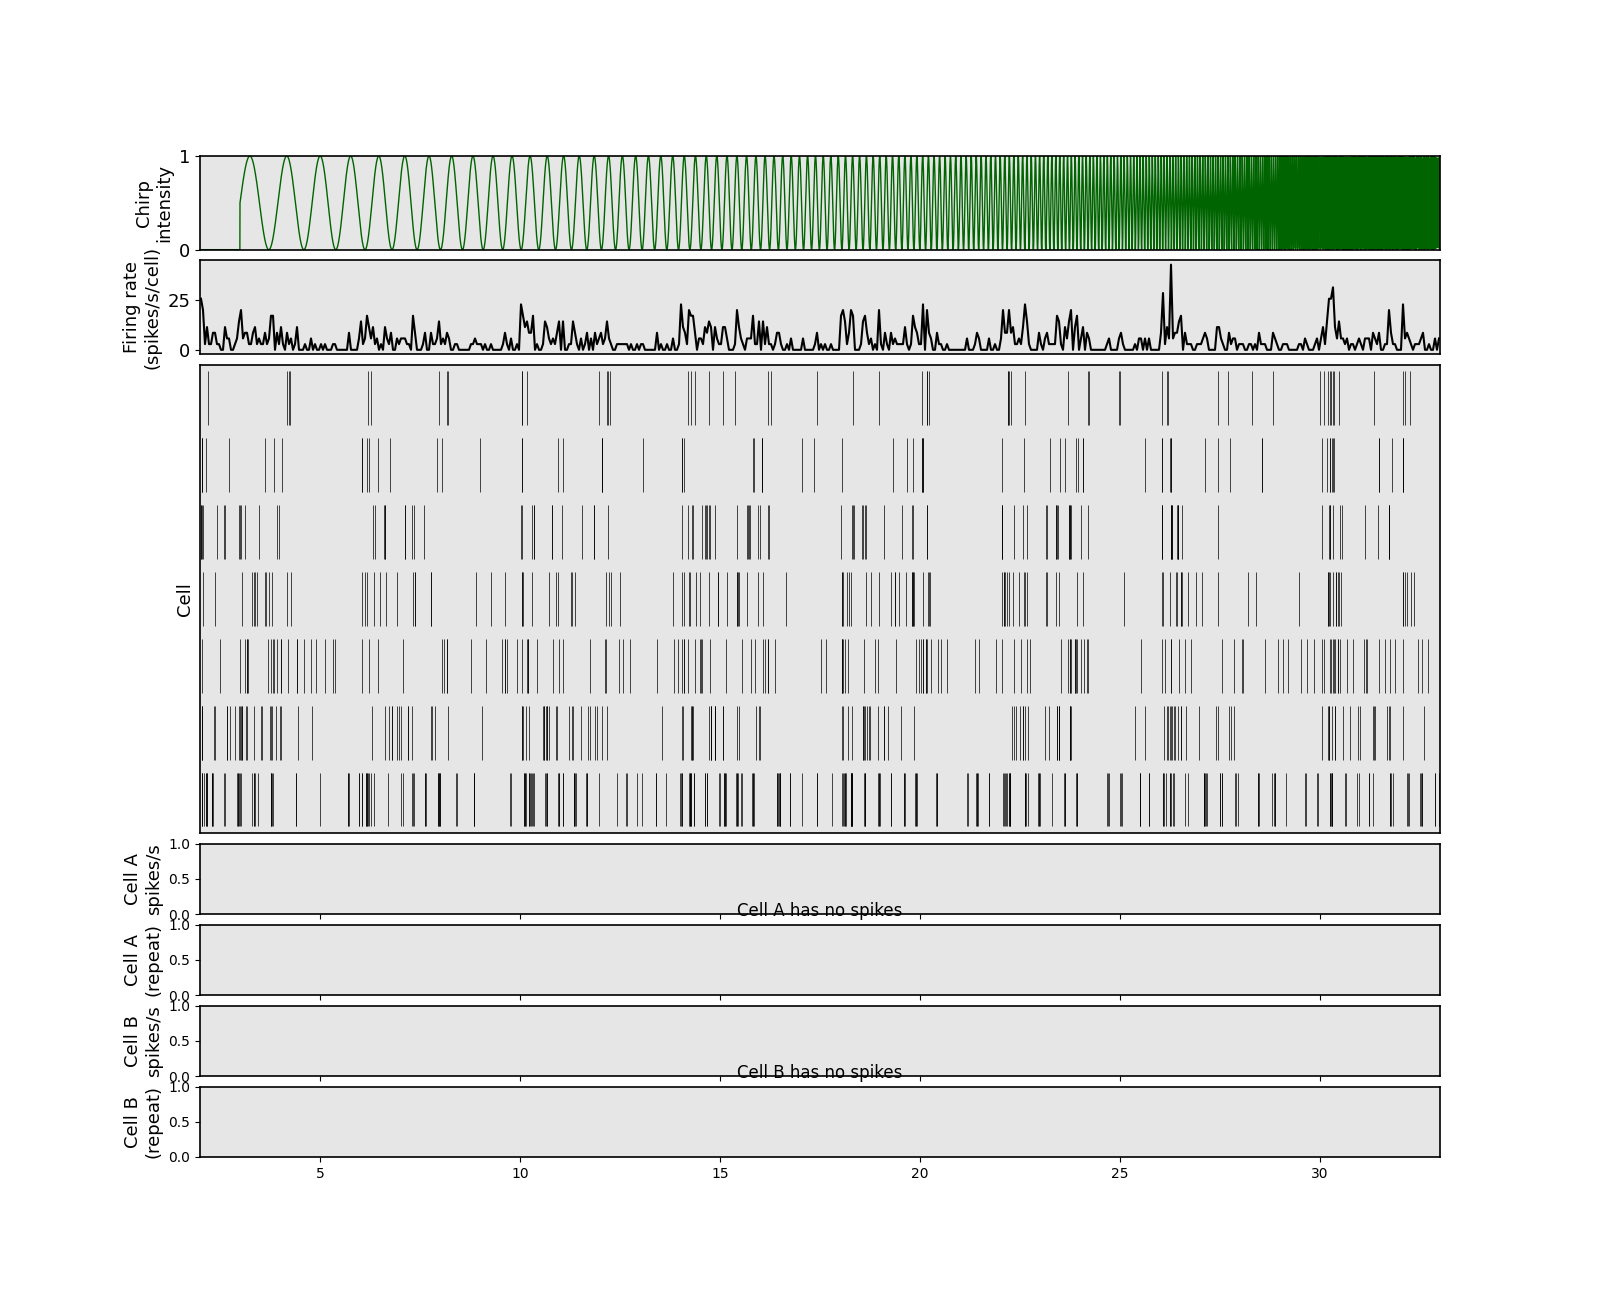

In [6]:
metrics = plot_raster_with_mean_chirp(
    spikes,
    cell_thresholds=cell_thresholds,
    full_time_axis=full_time_axis,
    pwm_trace=chirp_complete,
    single_cells=[175,168],
    t_start = 2,
    t_end = 33,
)